# Polymarket `orderFilled` — Financial Data Analysis

**Period:** 2022-11 → 2025-10 (~151M trades)

**Source:** `data/orderFilled/year=*/month=*/month.parquet` (Hive-partitioned, generated from `orderFilled_complete.csv.xz` via `scripts/migrate_orderfilled_xz.py`).

### What Polymarket is (in 60 seconds)

Polymarket is a *prediction market*: people buy and sell "shares" that pay $1 if a specific real-world event happens, and $0 if it doesn't. A share trading at $0.62 is the market saying "we think there's a 62% chance this happens." The Conditional Token Framework (CTF) is the on-chain plumbing that mints these YES/NO outcome tokens; USDC (a US-dollar stablecoin) is the cash side.

Every row in this dataset is one *fill* — a moment when two orders matched on the exchange. The **maker** is the trader who placed a resting limit order (waited at a price); the **taker** is the trader who came in and crossed it. One side of the trade is paying USDC, the other is delivering outcome shares.

### Schema cheat-sheet

| col | meaning |
|-----|--------|
| `timestamp` | unix seconds (seconds since 1970-01-01 UTC) |
| `maker` / `taker` | Polygon EOA addresses (a wallet — like a bank-account number on the blockchain) |
| `makerAssetId` / `takerAssetId` | CTF token id (256-bit, stored as string). `'0'` = USDC collateral; any other value = a specific outcome share |
| `makerAmountFilled` / `takerAmountFilled` | raw integer amounts (USDC and CTF shares both have 6 decimals — divide by 1,000,000 to get human units) |
| `transactionHash` | Polygon tx hash (the unique ID of the on-chain transaction this fill was packaged in) |
| `id` | synthetic `legacy:<row_idx>` (our internal row number) |

### Direction & implied price

A fill where the maker pays USDC and receives shares is a **maker-buy** (the maker is going long the outcome — betting it happens). A fill where the maker delivers shares and receives USDC is a **maker-sell** (betting against / exiting).

The **implied price** = `notional_usdc / shares`. Because the share pays $1 if the event happens and $0 otherwise, the price is bounded `[0, 1]` and reads directly as a probability (price 0.62 ↔ market-implied 62% probability).

### How we run this

Heavy aggregations run on **DuckDB** (an in-process SQL engine that streams data off disk so it doesn't have to fit in RAM); DuckDB hands small result tables to **Polars** / **Matplotlib** / **Seaborn** for reshaping and plotting.

## 1. Setup

We open a DuckDB connection (think of it as a tiny embedded database), point it at all the Parquet files at once via a `read_parquet` glob, and define two SQL **views** — saved queries that look like tables:

- `raw` — the literal contents of the Parquet files (one row per fill, raw integer amounts).
- `trades` — the same data **normalised**: timestamps converted to a real datetime, `notional_usdc` and `shares` extracted into clean columns regardless of whether the maker or the taker was on the USDC side, and a `maker_side` flag of `buy` or `sell` from the maker's perspective.

The `LIMIT 3` preview at the bottom shows three sample fills so you can sanity-check the columns.

In [1]:
from __future__ import annotations

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DATA_GLOB = "../data/orderFilled/**/*.parquet"
assert any(Path("../data/orderFilled").rglob("*.parquet")), (
    "missing parquet data \u2014 run scripts/migrate_orderfilled_xz.py first"
)

con = duckdb.connect()
con.execute("SET memory_limit='6GB'")
con.execute(f"SET temp_directory='{Path('./_duckdb_tmp').resolve().as_posix()}'")
con.execute(
    f"""
    CREATE OR REPLACE VIEW raw AS
    SELECT * FROM read_parquet('{DATA_GLOB}', hive_partitioning=true)
    """
)
con.execute(
    """
    CREATE OR REPLACE VIEW trades AS
    SELECT
      to_timestamp("timestamp")::TIMESTAMP        AS ts,
      "timestamp"                                AS ts_unix,
      year, month,
      maker, taker, transactionHash, id,
      CASE WHEN makerAssetId = '0' THEN makerAmountFilled ELSE takerAmountFilled END / 1e6 AS notional_usdc,
      CASE WHEN makerAssetId = '0' THEN takerAmountFilled ELSE makerAmountFilled END / 1e6 AS shares,
      CASE WHEN makerAssetId = '0' THEN takerAssetId ELSE makerAssetId END AS ctf_id,
      CASE WHEN makerAssetId = '0' THEN 'buy' ELSE 'sell' END AS maker_side
    FROM raw
    """
)
con.sql("SELECT * FROM trades LIMIT 3").pl()

ts,ts_unix,year,month,maker,taker,transactionHash,id,notional_usdc,shares,ctf_id,maker_side
datetime[μs],i64,i64,i64,str,str,str,str,f64,f64,str,str
2022-11-21 20:50:09,1669060209,2022,11,"""0xea5981ca48dc40c950fc1b2496c4…","""0x4bfb41d5b3570defd03c39a9a4d8…","""0x05a7f9b0b016d7e431b4e62b3748…","""legacy:0""",50.0,100.0,"""658186196575688134743418686523…","""sell"""
2022-11-21 20:50:09,1669060209,2022,11,"""0xea5981ca48dc40c950fc1b2496c4…","""0xea5981ca48dc40c950fc1b2496c4…","""0x05a7f9b0b016d7e431b4e62b3748…","""legacy:1""",50.0,100.0,"""658186196575688134743418686523…","""buy"""
2022-11-21 20:52:13,1669060333,2022,11,"""0xea5981ca48dc40c950fc1b2496c4…","""0x4bfb41d5b3570defd03c39a9a4d8…","""0x3a5412c9d8129e8a27ddb43cdf60…","""legacy:2""",60.0,100.0,"""658186196575688134743418686523…","""sell"""


## 2. Headline metrics

A handful of single numbers that describe the whole dataset at a glance.

- **trades** — total number of fills (matched orders) over three years.
- **volume_usdc** — total USDC notional traded (sum of every fill's USDC leg). The standard "size of the venue" number you'd see quoted in news.
- **avg_trade** — mean fill size in USDC. Pulled up by whales.
- **median_trade** — the middle fill size; a typical fill. Closer to the retail experience than the mean.
- **unique_makers / unique_takers** — distinct wallet addresses that have ever placed a resting / crossing order. Counted with **HyperLogLog** (`approx_count_distinct`), a probabilistic algorithm that gets you within ~1% of the true count in seconds rather than minutes — exact distinct counts on 151M rows would force the query to spill huge hash tables to disk.
- **unique_outcomes** — distinct CTF outcome tokens traded. Each binary market has a YES token and a NO token, so this is roughly `2 × number_of_markets`.

In [2]:
headline = con.sql("""
    SELECT
      count(*)                              AS trades,
      sum(notional_usdc)                    AS volume_usdc,
      avg(notional_usdc)                    AS avg_trade,
      approx_quantile(notional_usdc, 0.5)   AS median_trade,
      approx_count_distinct(maker)          AS unique_makers,
      approx_count_distinct(taker)          AS unique_takers,
      approx_count_distinct(ctf_id)         AS unique_outcomes
    FROM trades
""").pl().to_dicts()[0]

for k, v in headline.items():
    if isinstance(v, float):
        print(f"{k:>20}: {v:,.4f}")
    else:
        print(f"{k:>20}: {v:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

              trades: 151,053,823
         volume_usdc: 18,885,941,519.2690
           avg_trade: 125.0279
        median_trade: 7.5051
       unique_makers: 1,645,990
       unique_takers: 1,645,990
     unique_outcomes: 196,684


## 3. Monthly volume & activity

Polymarket's volume is event-driven (US elections, Fed rate decisions, sports finals, crypto launches), so we plot three monthly time-series rather than fit a smooth growth curve. Expect step-jumps around major events.

- **Top panel** — total USDC notional traded each month, in millions. The headline "how big was the venue this month" number.
- **Middle panel** — number of fills per month (log scale). Captures activity intensity independently of trade size.
- **Bottom panel** — distinct active wallets each month, makers and takers (log scale). A proxy for how many *people* are using the venue, as opposed to how much money is moving.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

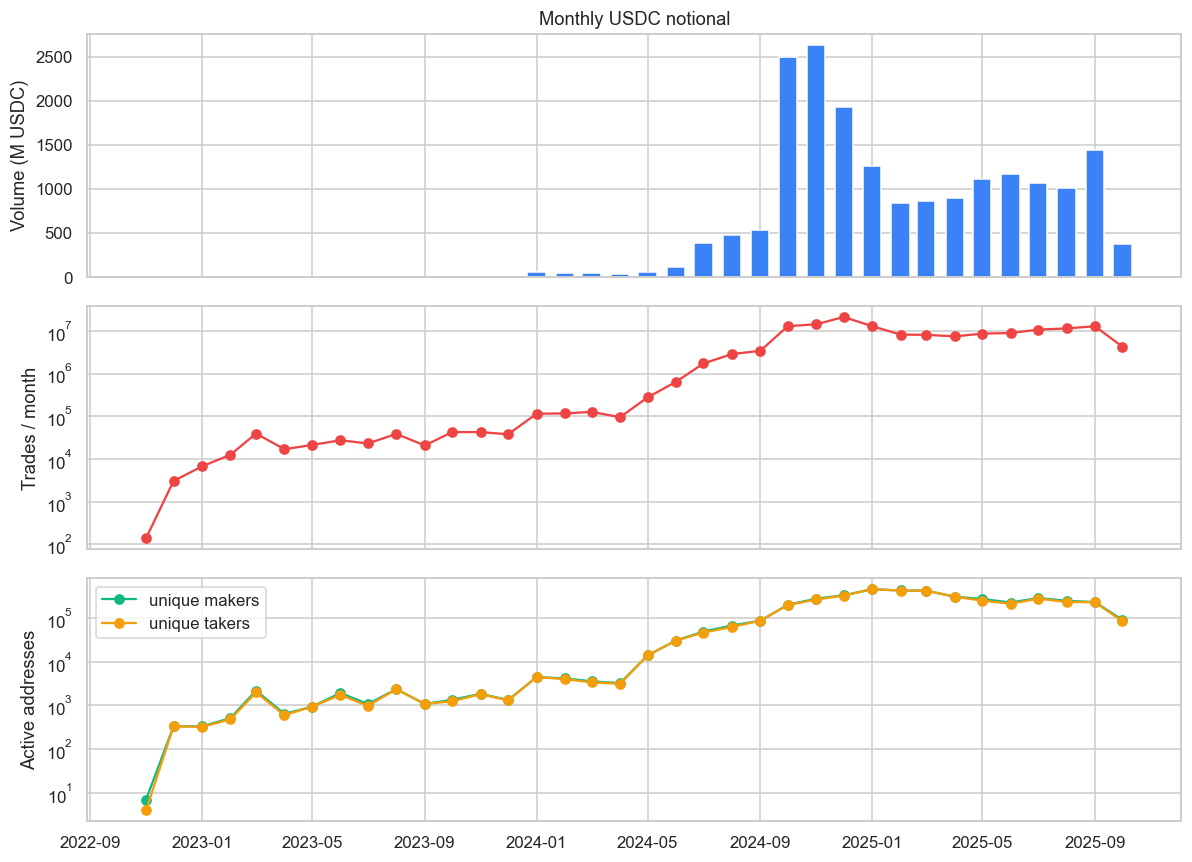

year,month,volume_usdc,trades,makers,takers,outcomes,date
i64,i64,f64,i64,i64,i64,i64,date
2022,11,1458.169851,138,7,4,2,2022-11-01
2022,12,341132.563064,3023,335,335,101,2022-12-01
2023,1,1.2469e6,6669,332,324,172,2023-01-01
2023,2,2.8827e6,12461,514,483,636,2023-02-01
2023,3,1.1421e7,39210,2172,1979,757,2023-03-01
…,…,…,…,…,…,…,…
2025,6,1.1651e9,8893392,224733,210102,19506,2025-06-01
2025,7,1.0653e9,10683501,285118,275778,23151,2025-07-01
2025,8,1.0079e9,11410511,245224,231172,28417,2025-08-01


In [3]:
monthly = con.sql("""
    SELECT year, month,
           sum(notional_usdc)                AS volume_usdc,
           count(*)                          AS trades,
           approx_count_distinct(maker)      AS makers,
           approx_count_distinct(taker)      AS takers,
           approx_count_distinct(ctf_id)     AS outcomes
    FROM trades
    GROUP BY year, month
    ORDER BY year, month
""").pl().with_columns(
    pl.date(pl.col("year"), pl.col("month"), 1).alias("date")
)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].bar(monthly["date"], monthly["volume_usdc"] / 1e6, color="#3b82f6", width=20)
axes[0].set_ylabel("Volume (M USDC)")
axes[0].set_title("Monthly USDC notional")
axes[1].plot(monthly["date"], monthly["trades"], color="#ef4444", marker="o")
axes[1].set_ylabel("Trades / month")
axes[1].set_yscale("log")
axes[2].plot(monthly["date"], monthly["makers"], color="#10b981", marker="o", label="unique makers")
axes[2].plot(monthly["date"], monthly["takers"], color="#f59e0b", marker="o", label="unique takers")
axes[2].set_ylabel("Active addresses")
axes[2].set_yscale("log")
axes[2].legend()
plt.tight_layout()
plt.show()

monthly

## 4. Maker-side directional flow

Every trade has two sides; this chart asks **which side is the patient one**.

- A *maker* posts a resting limit order — "I'll trade at this price if someone wants to come hit me." They **provide liquidity**.
- A *taker* crosses the spread — "I want this trade now, at whatever price the book is showing." They **demand liquidity**.

If makers are dominated by *buys* (USDC → shares), it means the patient capital on the venue is leaning long, and the impatient flow (takers) is selling into them. If maker-sells dominate, it's the opposite — patient sellers absorbing impatient buyers. Reading this over time tells you how directional sentiment shifts.

The chart stacks maker-buys above the zero line (green) and maker-sells below (red). The printout at the bottom is the global maker-buy share of total volume — 50% means perfectly balanced.

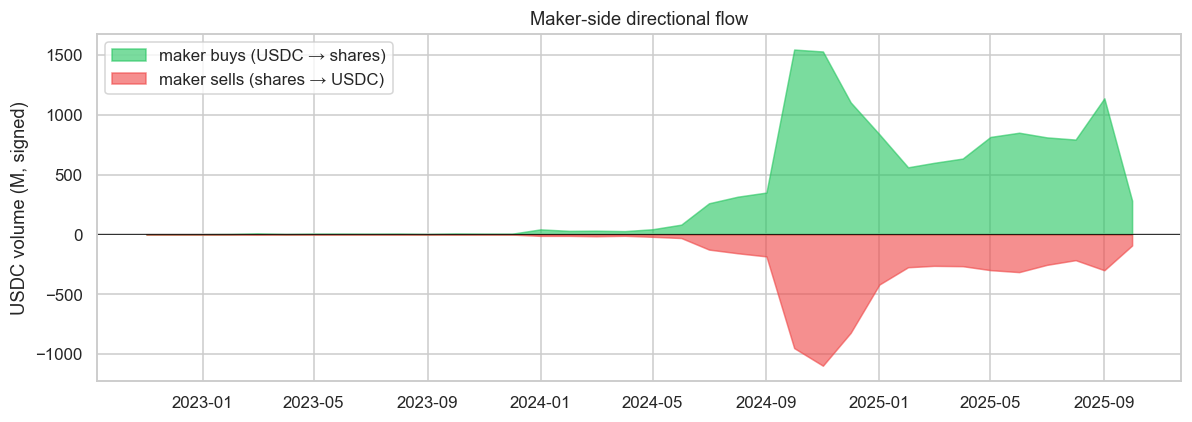

global maker-buy share of volume: 67.36%


In [4]:
flow_long = con.sql("""
    SELECT year, month, maker_side, sum(notional_usdc) AS vol
    FROM trades
    GROUP BY year, month, maker_side
    ORDER BY year, month, maker_side
""").pl()

flow = (
    flow_long.pivot(values="vol", index=["year", "month"], on="maker_side")
    .fill_null(0.0)
    .with_columns(pl.date(pl.col("year"), pl.col("month"), 1).alias("date"))
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(flow["date"], 0, flow["buy"] / 1e6, color="#22c55e", alpha=0.6,
                label="maker buys (USDC \u2192 shares)")
ax.fill_between(flow["date"], 0, -flow["sell"] / 1e6, color="#ef4444", alpha=0.6,
                label="maker sells (shares \u2192 USDC)")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("USDC volume (M, signed)")
ax.set_title("Maker-side directional flow")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

buy_share = flow["buy"].sum() / (flow["buy"].sum() + flow["sell"].sum())
print(f"global maker-buy share of volume: {buy_share:.2%}")

## 5. Trade-size distribution

Polymarket has a wide range of users — somebody YOLOing $5 on a sports market sits in the same dataset as a market-maker doing $1M prints. To see the whole picture without materialising 151M floats in memory:

- **Approximate quantiles** (`approx_quantile`, t-digest sketch under the hood). The 50th percentile is the median; 99th means "1% of trades are bigger than this"; 99.9th is the whale tail. Comparing the mean to the median tells you how skewed the distribution is — typical retail-heavy fintech data has mean ≫ median.
- **Log-bucketed histogram**. We bucket fills by `floor(log10(notional))` so each bar covers a multiplicative range: bar `0` = $1–$10 fills, bar `1` = $10–$100, bar `2` = $100–$1k, etc. The y-axis is also log because the bars span many orders of magnitude. This is the standard view for power-law-like data.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    p50: $          7.50
    p75: $         39.24
    p90: $        139.04
    p95: $        330.89
    p99: $      1,997.71
  p99_9: $     13,271.84
   mean: $        125.03
    min: $          0.00
    max: $  2,478,476.45


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

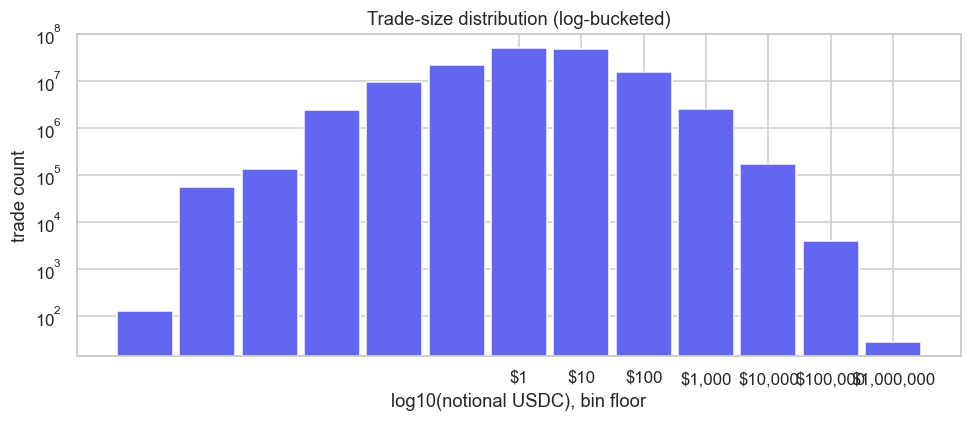

In [5]:
qs = con.sql("""
    SELECT
      approx_quantile(notional_usdc, 0.50)   AS p50,
      approx_quantile(notional_usdc, 0.75)   AS p75,
      approx_quantile(notional_usdc, 0.90)   AS p90,
      approx_quantile(notional_usdc, 0.95)   AS p95,
      approx_quantile(notional_usdc, 0.99)   AS p99,
      approx_quantile(notional_usdc, 0.999)  AS p99_9,
      avg(notional_usdc)                     AS mean,
      min(notional_usdc)                     AS min,
      max(notional_usdc)                     AS max
    FROM trades
    WHERE notional_usdc > 0
""").pl().to_dicts()[0]
for k, v in qs.items():
    print(f"  {k:>5}: ${v:>14,.2f}")

size_hist = con.sql("""
    SELECT cast(floor(log10(notional_usdc)) AS INTEGER) AS logbin,
           count(*) AS n
    FROM trades
    WHERE notional_usdc > 0
    GROUP BY logbin
    ORDER BY logbin
""").pl()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(size_hist["logbin"], size_hist["n"], color="#6366f1", width=0.9)
ax.set_yscale("log")
ax.set_xlabel("log10(notional USDC), bin floor")
ax.set_ylabel("trade count")
ax.set_title("Trade-size distribution (log-bucketed)")
tick_dollars = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]
ax.set_xticks([np.log10(d) for d in tick_dollars])
ax.set_xticklabels([f"${d:,}" for d in tick_dollars])
plt.tight_layout()
plt.show()

## 6. Top markets by volume

We don't carry human-readable titles ("Will Trump win the 2024 election?") at this layer — they live in the `markets` table populated by `poly-data update-markets`. So the top outcomes appear as raw 256-bit CTF token ids, truncated for readability.

Per-outcome we report:

- **volume_usdc** — total USDC traded *in this outcome*. The biggest markets are typically major-election YES/NO tokens.
- **trades** — number of fills. High volume + low trade count = a few whales; high volume + high trade count = retail crowd.
- **unique_makers / unique_takers** — distinct wallets on each side. Strong asymmetry (e.g. lots of makers, few takers) often signals a directional consensus market.
- **avg_price** — average implied price across all fills, clipped to [0,1]. Markets near 0.5 spent most of their life as a coin-flip; near 0.95 they were heavy favourites; near 0.05 they were heavy underdogs.

In [6]:
top_outcomes = con.sql("""
    SELECT
      ctf_id,
      sum(notional_usdc)                AS volume_usdc,
      count(*)                          AS trades,
      approx_count_distinct(maker)      AS unique_makers,
      approx_count_distinct(taker)      AS unique_takers,
      avg(price_clipped) FILTER (WHERE price_finite) AS avg_price
    FROM (
      SELECT *,
             notional_usdc / NULLIF(shares, 0) AS price,
             CASE WHEN shares > 0 THEN GREATEST(0, LEAST(1, notional_usdc / shares)) END AS price_clipped,
             shares > 0 AS price_finite
      FROM trades
    )
    WHERE ctf_id IS NOT NULL
    GROUP BY ctf_id
    ORDER BY volume_usdc DESC
    LIMIT 20
""").pl()

with pl.Config(fmt_str_lengths=24, tbl_rows=20):
    print(top_outcomes)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

shape: (20, 6)
┌───────────────────────────┬─────────────┬─────────┬───────────────┬───────────────┬───────────┐
│ ctf_id                    ┆ volume_usdc ┆ trades  ┆ unique_makers ┆ unique_takers ┆ avg_price │
│ ---                       ┆ ---         ┆ ---     ┆ ---           ┆ ---           ┆ ---       │
│ str                       ┆ f64         ┆ i64     ┆ i64           ┆ i64           ┆ f64       │
╞═══════════════════════════╪═════════════╪═════════╪═══════════════╪═══════════════╪═══════════╡
│ 217426331434639062905690… ┆ 1.2195e9    ┆ 3450272 ┆ 136748        ┆ 137328        ┆ 0.606165  │
│ 692369236200776910270839… ┆ 5.7053e8    ┆ 1752210 ┆ 137135        ┆ 137525        ┆ 0.395126  │
│ 457148706340909084038137… ┆ 4.7064e8    ┆ 1736116 ┆ 119731        ┆ 95001         ┆ 0.962668  │
│ 483310433366128838909387… ┆ 4.1664e8    ┆ 1659347 ┆ 77890         ┆ 124765        ┆ 0.389308  │
│ 875849553592452464049521… ┆ 3.1634e8    ┆ 1060734 ┆ 71242         ┆ 102615        ┆ 0.608117  │
│ 343

## 7. Trader concentration (Lorenz / Gini)

**Question:** is volume spread evenly across users, or do a handful of whales dominate?

- The **Lorenz curve** plots cumulative volume share (y) against cumulative trader percentile sorted from least active to most active (x). The 45° dashed line is the "perfect equality" baseline — every trader doing equal volume. The further the actual curve sags below it, the more concentrated the volume is.
- The **Gini coefficient** is a single-number summary of that gap: `0` = perfect equality, `1` = one person does all the volume. Gini > `0.6` is highly concentrated; values above `0.9` are common in crypto-native venues where a few professional market-makers do most of the volume. (The same metric is used in economics to measure income inequality.)

We also print the share of total volume captured by the top 10, top 100, and top 1% of makers — a sanity check on the Gini number.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

unique makers:  1,309,191
Gini(maker volume): 0.9464
top 10 makers:  5.85% of volume
top 100 makers: 21.32% of volume
top 1% makers:  76.94% of volume

Top 10 makers:
shape: (10, 2)
┌─────────────────────────────────┬──────────┐
│ maker                           ┆ vol      │
│ ---                             ┆ ---      │
│ str                             ┆ f64      │
╞═════════════════════════════════╪══════════╡
│ 0xd218e474776403a330142299f779… ┆ 2.0936e8 │
│ 0x5bffcf561bcae83af680ad600cb9… ┆ 1.4272e8 │
│ 0x9d84ce0306f8551e02efef168047… ┆ 1.1912e8 │
│ 0x63d43bbb87f85af03b8f2f9e2fad… ┆ 1.0128e8 │
│ 0x24c8cf69a0e0a17eee21f69d2975… ┆ 9.3590e7 │
│ 0x44c1dfe43260c94ed4f1d00de2e1… ┆ 9.0458e7 │
│ 0xf8ba34bf0e95d952d05b578bfbc0… ┆ 8.8328e7 │
│ 0xc6587b11a2209e46dfe3928b31c5… ┆ 8.6965e7 │
│ 0xee00ba338c59557141789b127927… ┆ 8.6678e7 │
│ 0xfffe4013adfe325c6e02d36dc66e… ┆ 8.6427e7 │
└─────────────────────────────────┴──────────┘


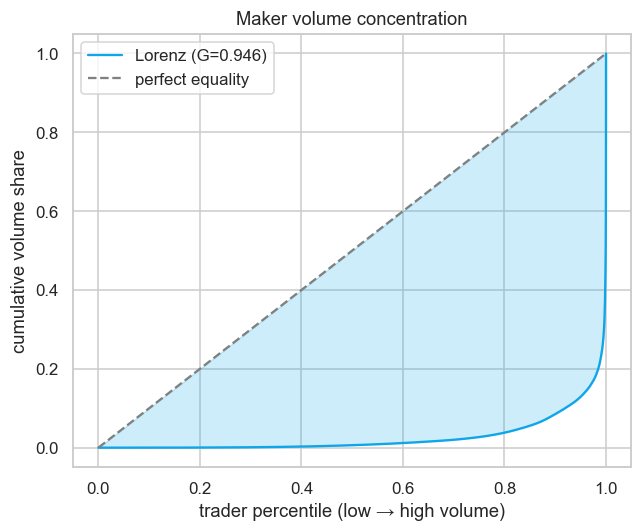

In [7]:
def gini(x: np.ndarray) -> float:
    x = np.sort(x.astype(np.float64))
    n = x.size
    if n == 0 or x.sum() == 0:
        return 0.0
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))

trader_vol = con.sql("""
    SELECT maker, sum(notional_usdc) AS vol
    FROM trades
    GROUP BY maker
    ORDER BY vol DESC
""").pl()

v = trader_vol["vol"].to_numpy()
g = gini(v)
total_vol = v.sum()
print(f"unique makers:  {trader_vol.height:,}")
print(f"Gini(maker volume): {g:.4f}")
print(f"top 10 makers:  {v[:10].sum() / total_vol:.2%} of volume")
print(f"top 100 makers: {v[:100].sum() / total_vol:.2%} of volume")
print(f"top 1% makers:  {v[:max(1, trader_vol.height // 100)].sum() / total_vol:.2%} of volume")
print("\nTop 10 makers:")
print(trader_vol.head(10))

vs = np.sort(v)
cum = np.cumsum(vs) / vs.sum()
x = np.arange(1, len(vs) + 1) / len(vs)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(x, cum, color="#0ea5e9", label=f"Lorenz (G={g:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect equality")
ax.fill_between(x, cum, x, alpha=0.2, color="#0ea5e9")
ax.set_xlabel("trader percentile (low \u2192 high volume)")
ax.set_ylabel("cumulative volume share")
ax.set_title("Maker volume concentration")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 8. Activity by weekday and UTC hour

Prediction markets aren't timezone-neutral. Polymarket flow is heavily US-driven, so volume should peak when the US east coast is awake (~14:00–23:00 UTC, i.e. 9am–6pm Eastern). Weekday vs. weekend matters too: macro-news markets quiet down outside US business hours, sports markets light up on game days.

The **heatmap** has weekdays on the rows (Monday at the top, Sunday at the bottom) and UTC hours 0–23 on the columns; darker red = more USDC volume. Read it like a clock for the venue.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

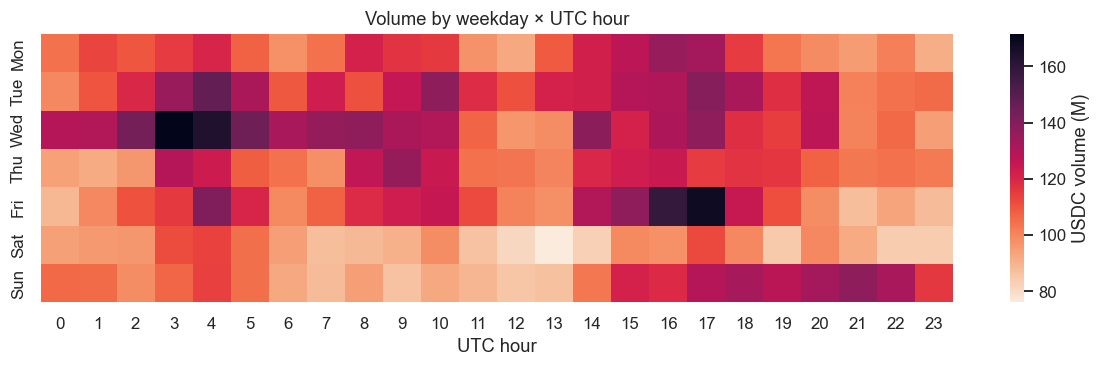

In [8]:
clock = con.sql("""
    SELECT
      ((dayofweek(ts) + 6) % 7) AS dow,            -- 0=Mon..6=Sun
      hour(ts)                  AS hour,
      sum(notional_usdc)        AS vol
    FROM trades
    GROUP BY dow, hour
    ORDER BY dow, hour
""").pl()

mat = np.zeros((7, 24), dtype=float)
for row in clock.iter_rows(named=True):
    mat[row["dow"], row["hour"]] = row["vol"]

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(
    mat / 1e6,
    ax=ax,
    cmap="rocket_r",
    cbar_kws={"label": "USDC volume (M)"},
    xticklabels=list(range(24)),
    yticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
)
ax.set_xlabel("UTC hour")
ax.set_ylabel("")
ax.set_title("Volume by weekday \u00d7 UTC hour")
plt.tight_layout()
plt.show()

## 9. Self-trade rate

When the same wallet appears as both maker and taker on a single fill (`maker == taker`), they've literally traded with themselves. Reasons range from benign (intra-custodian rebalancing across sub-accounts; multi-leg strategies routed through one address; exchange-side rebate harvesting) to outright **wash trading** — faking volume to look more active to outsiders. On a healthy regulated venue this stays well under 1%.

The chart shows the self-trade rate over time, both **by trade count** (orange bars) and **by USDC volume** (red line). A volume-weighted spike with a flat count rate suggests a few large addresses doing big self-prints; the inverse pattern suggests many small benign cases.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

global self-trade rate (count):  0.0006%
global self-trade rate (volume): 0.0012%


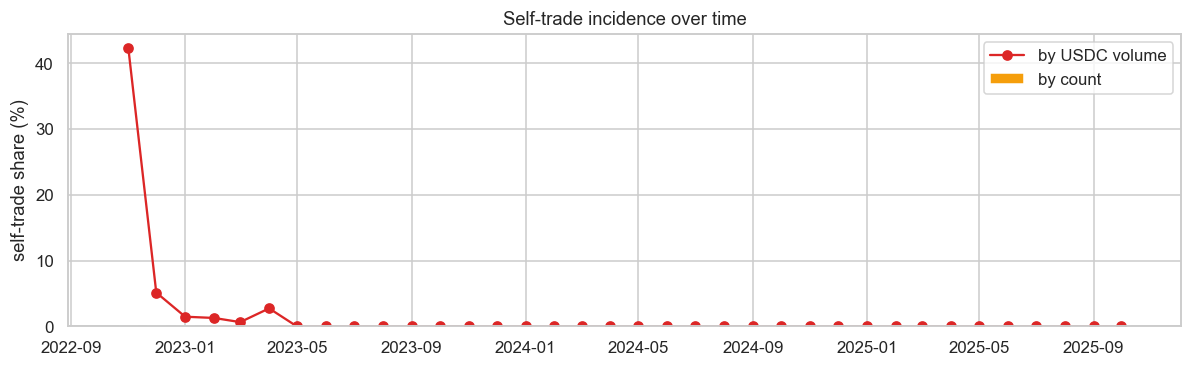

In [9]:
wash = con.sql("""
    SELECT year, month,
           sum(case when maker = taker then 1 else 0 end)              AS self_trades,
           count(*)                                                    AS total,
           sum(case when maker = taker then notional_usdc else 0 end)  AS self_vol,
           sum(notional_usdc)                                          AS total_vol
    FROM trades
    GROUP BY year, month
    ORDER BY year, month
""").pl().with_columns(
    (pl.col("self_trades") / pl.col("total")).alias("self_rate"),
    (pl.col("self_vol") / pl.col("total_vol")).alias("self_vol_rate"),
    pl.date(pl.col("year"), pl.col("month"), 1).alias("date"),
)

print(f"global self-trade rate (count):  {wash['self_trades'].sum() / wash['total'].sum():.4%}")
print(f"global self-trade rate (volume): {wash['self_vol'].sum() / wash['total_vol'].sum():.4%}")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(wash["date"], wash["self_rate"] * 100, color="#f59e0b", label="by count", width=20)
ax.plot(wash["date"], wash["self_vol_rate"] * 100, color="#dc2626", marker="o", label="by USDC volume")
ax.set_ylabel("self-trade share (%)")
ax.set_title("Self-trade incidence over time")
ax.legend()
plt.tight_layout()
plt.show()

## 10. New-trader cohort

For each maker address we record the **first time** it ever shows up on the venue (a "cohort" in marketing-analytics jargon — the group of users who first arrived in a given period). Bucketed by month, this gives you a user-acquisition curve.

Spikes correspond to user-acquisition events — new product launches, viral markets, or (the obvious one for Polymarket) the 2024 US presidential election cycle, which drove a massive influx of first-time accounts.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

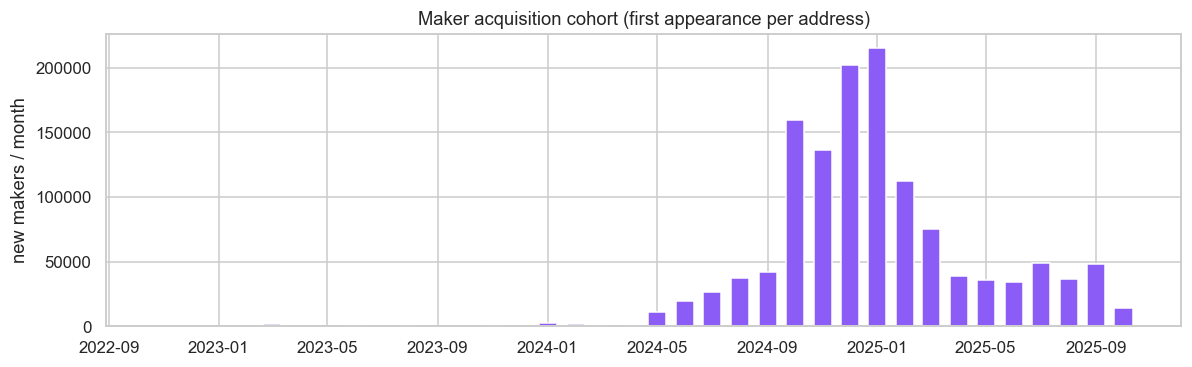

In [10]:
first_seen = con.sql("""
    WITH per_maker AS (
        SELECT maker, min(ts) AS first FROM trades GROUP BY maker
    )
    SELECT year(first) AS year, month(first) AS month, count(*) AS new_makers
    FROM per_maker
    GROUP BY year, month
    ORDER BY year, month
""").pl().with_columns(
    pl.date(pl.col("year"), pl.col("month"), 1).alias("date")
)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(first_seen["date"], first_seen["new_makers"], color="#8b5cf6", width=20)
ax.set_ylabel("new makers / month")
ax.set_title("Maker acquisition cohort (first appearance per address)")
plt.tight_layout()
plt.show()

## 11. Implied-price sanity

Every honest CTF outcome share pays $1 if the event happens and $0 if it doesn't, so the implied price (`USDC / shares`) is a probability and **must live between 0 and 1**. A fill outside that range is either bad data or an exotic settlement edge case. We check what fraction of fills are in band, then plot a 1¢-binned histogram (each bar covers 1¢ of price).

Healthy distributions are **bimodal**: lots of mass near 0 (long-shot underdogs) and 1 (heavy favourites), with a thinner middle for genuinely uncertain markets. A flat or unimodal distribution would be unusual.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

finite-price fills: 151,053,823
inside [0, 1]:      151,053,822  (100.0000%)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

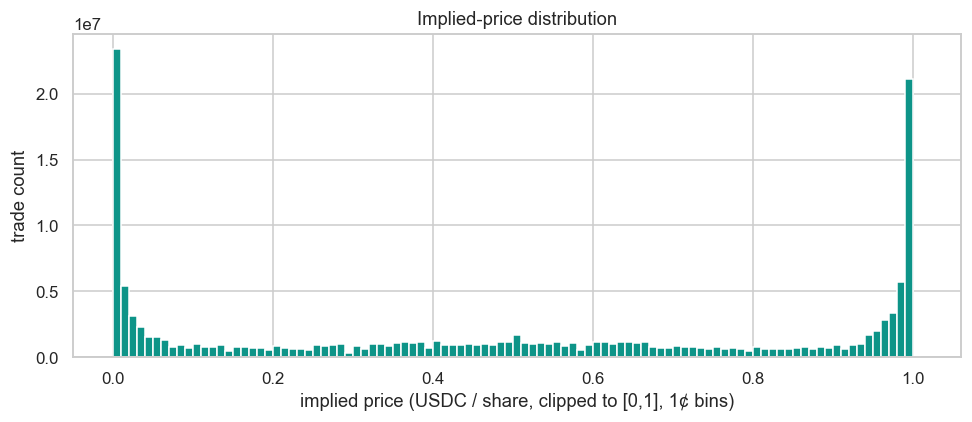

In [11]:
in_band = con.sql("""
    SELECT
      count(*)                                                       AS total,
      sum(case when price >= 0 and price <= 1 then 1 else 0 end)     AS in_band
    FROM (
      SELECT notional_usdc / shares AS price
      FROM trades
      WHERE shares > 0
    )
""").pl().to_dicts()[0]
print(f"finite-price fills: {in_band['total']:,}")
print(f"inside [0, 1]:      {in_band['in_band']:,}  ({in_band['in_band'] / in_band['total']:.4%})")

px_hist = con.sql("""
    SELECT cast(floor(GREATEST(0, LEAST(1, notional_usdc / shares)) * 100) AS INTEGER) AS bin,
           count(*) AS n
    FROM trades
    WHERE shares > 0
    GROUP BY bin
    ORDER BY bin
""").pl()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(px_hist["bin"] / 100, px_hist["n"], width=0.01, color="#0d9488", align="edge")
ax.set_xlabel("implied price (USDC / share, clipped to [0,1], 1\u00a2 bins)")
ax.set_ylabel("trade count")
ax.set_title("Implied-price distribution")
plt.tight_layout()
plt.show()

## 12. Summary

The dataset captures Polymarket's full retail-to-whale spread across 36 monthly partitions. Volume is tightly correlated with US political and macro events; the long tail of small fills coexists with a small set of dominant market-makers. Useful next steps:

- **Join `ctf_id` against the `markets` table** (populated by `poly-data update-markets`) to recover human-readable questions and outcome labels.
- **Per-market microstructure** — pull a price time-series for one `ctf_id` and compute *slippage* (the gap between your fill price and the prevailing midprice), spread, and tick-by-tick volatility.
- **Realised PnL per address** — cross with the `trades` (positions) table to get redemption-aware PnL, not just last-fill mark-to-market.
- For research-grade cuts that need one row per Polygon transaction (a single tx can settle many fills), deduplicate by `transactionHash`.